In [1]:
import pandas as pd

# Chemin vers le fichier
file_path = "facebook_reviews_disneylandParis.csv"

# Chargement du CSV
df = pd.read_csv(file_path)

# Aperçu des premières lignes
df.head()

,user_id,review,stars,date_format,time_of_day,hour_of_day,day_of_week,review_format,review_lang,month_year,review_len,review_nb_words
0,efb62a167fee5cf3678b24427de8e31f,"Génial, fabuleux, exceptionnel ! J'aimerais qu...",5,2017-09-29 18:17:00,18:17,18,Ven,génial fabuleux exceptionnel j aimerais qu...,french,2017-09,115,19
1,e3be4f9c9e0b9572bfb2a5f88497bb14,NaN,2,2017-09-29 17:29:00,17:29,17,Ven,NaN,NaN,2017-09,0,0
2,1b8e5760162d867e9b9ca80f645bdc60,"Toujours aussi magic, féerique !",5,2017-09-29 16:46:00,16:46,16,Ven,toujours aussi magic féerique,french,2017-09,32,4
3,fa330e5891a1bb486c3e9bf95c098726,NaN,5,2017-09-29 15:52:00,15:52,15,Ven,NaN,NaN,2017-09,0,0
4,c1a693206aee1a2412d4bd9e45b80ec5,NaN,3,2017-09-29 15:29:00,15:29,15,Ven,NaN,NaN,2017-09,0,0


In [2]:
# Suppression des lignes sans texte nettoyé
df_clean = df.dropna(subset=['review_format'])

# Conservation uniquement des avis en français
df_clean = df_clean[df_clean['review_lang'] == 'french']

# Aperçu des données filtrées
df_clean[['review_format', 'stars']].head()

,review_format,stars
0,génial fabuleux exceptionnel j aimerais qu...,5
2,toujours aussi magic féerique,5
11,en vacances en région parisienne nous nous som...,2
12,tropbeaufinalpleinlesyeuxoreil,5
23,l univers disney reste merveilleux toutefois ...,4


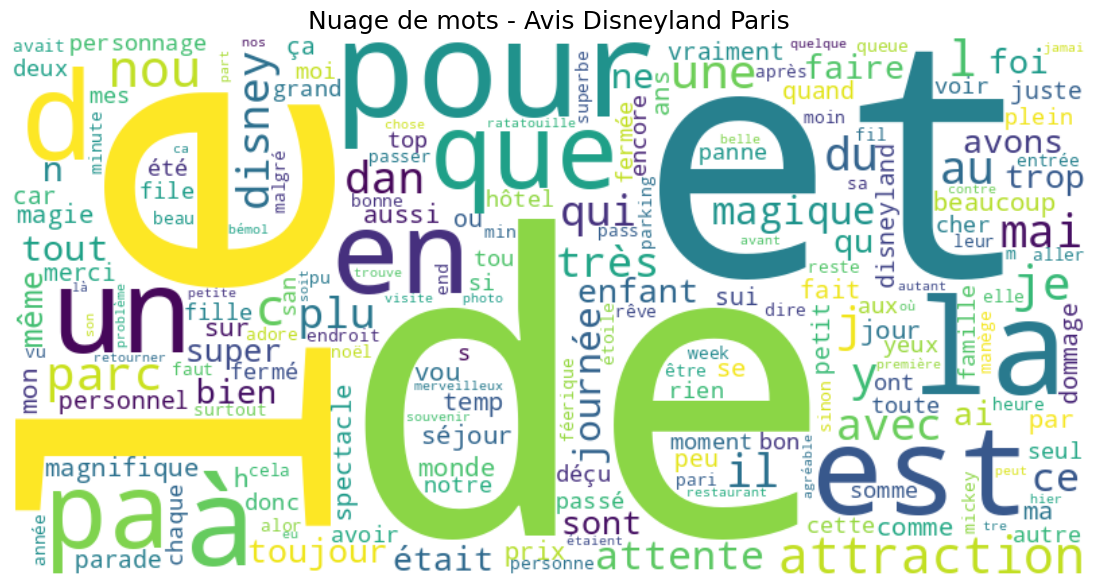

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fusion de tous les textes nettoyés
text_all_reviews = " ".join(df_clean['review_format'].astype(str))

# Génération du nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text_all_reviews)

# Affichage du nuage
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuage de mots - Avis Disneyland Paris", fontsize=18)
plt.show()

<ipython-input-4-ff47e97a2665>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='stars', palette='coolwarm')


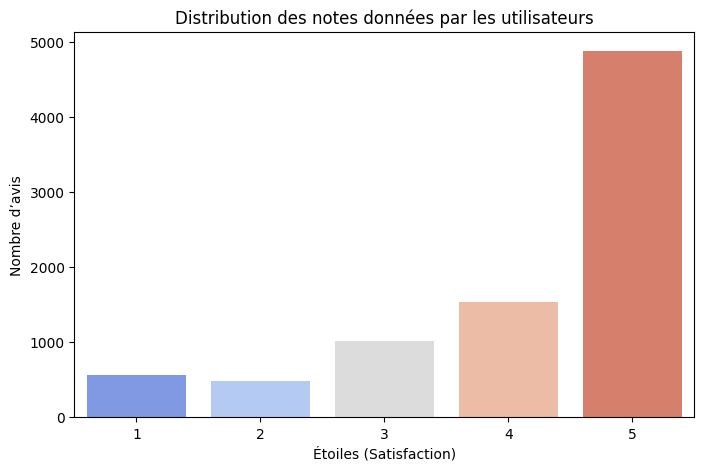

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage de la distribution des étoiles données par les utilisateurs
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='stars', palette='coolwarm')
plt.title("Distribution des notes données par les utilisateurs")
plt.xlabel("Étoiles (Satisfaction)")
plt.ylabel("Nombre d’avis")
plt.show()

In [5]:
# Création d'une variable sentiment basée sur les étoiles
# Positif : 4 ou 5 étoiles ; Négatif : 1 à 3 étoiles
df_clean['sentiment'] = df_clean['stars'].apply(lambda x: 'positif' if x >= 4 else 'négatif')

# Affichage de la répartition
df_clean['sentiment'].value_counts()

,count
sentiment,
positif,6419
négatif,2055


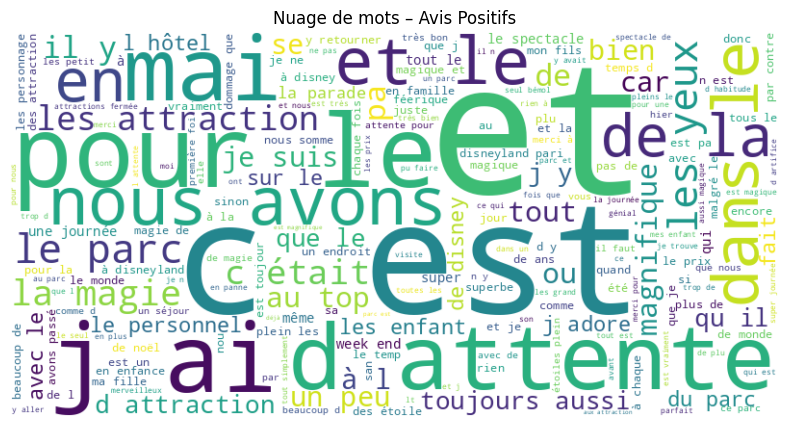

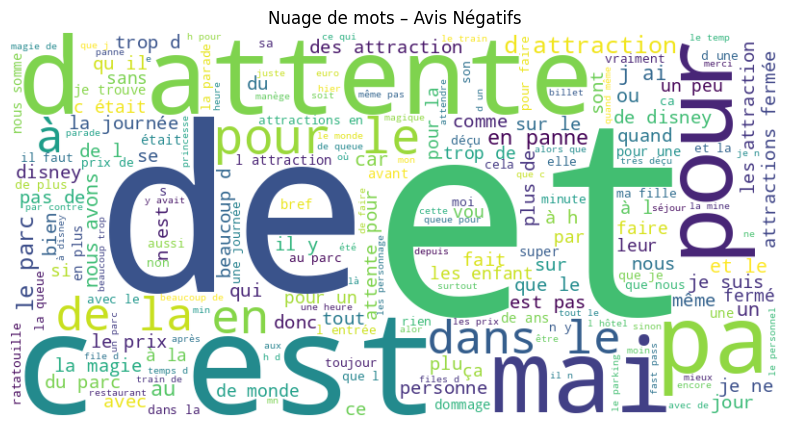

In [6]:
from wordcloud import STOPWORDS

# Texte concaténé pour chaque sentiment
text_positif = " ".join(df_clean[df_clean['sentiment'] == 'positif']['review_format'].astype(str))
text_negatif = " ".join(df_clean[df_clean['sentiment'] == 'négatif']['review_format'].astype(str))

# WordCloud pour avis positifs
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text_positif)
plt.figure(figsize=(15, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("Nuage de mots – Avis Positifs")
plt.show()

# WordCloud pour avis négatifs
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text_negatif)
plt.figure(figsize=(15, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Nuage de mots – Avis Négatifs")
plt.show()

In [7]:
from transformers import pipeline

# Modèle multilingue compatible avec le français
classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [8]:
# Test du modèle sur un avis tiré au hasard
exemple = df_clean['review_format'].sample(1).values[0]
resultat = classifier(exemple)
print(f"Avis : {exemple}")
print(f"Résultat : {resultat}")

Avis : génial  fabuleux  exceptionnel   j aimerais que walt disney se réveille pour admirer ce qu il à laissé derrière lui
Résultat : [{'label': '5 stars', 'score': 0.8855119347572327}]


In [9]:
# Attention : cette opération peut être lente (modèle lourd)
# Pour des raisons de performance, on commence par un échantillon de 100 avis (modifiable)

sample_df = df_clean.sample(100, random_state=42).copy()

# Appliquer le modèle sur la colonne 'review_format'
sample_df['model_prediction'] = sample_df['review_format'].apply(lambda x: classifier(x)[0]['label'])
sample_df['model_score'] = sample_df['review_format'].apply(lambda x: classifier(x)[0]['score'])

# Affichage des premiers résultats
sample_df[['review_format', 'stars', 'model_prediction', 'model_score']].head()

,review_format,stars,model_prediction,model_score
29231,magique rien de mieux pour se remonter le mor...,5,5 stars,0.718202
30340,trop de monde heures dans certaine attraction...,2,2 stars,0.375035
18428,nous adorons ce parc et ce depuis l ouverture ...,4,4 stars,0.332108
7716,fans absolus nous nous y rendons plusieurs fo...,4,3 stars,0.337357
2179,les cadeaux beaucoup trop chez et beaucoup tri...,5,2 stars,0.469861


In [10]:
# Extraire uniquement le chiffre de la prédiction texte ("4 stars" → 4)
sample_df['model_stars'] = sample_df['model_prediction'].str.extract('(\d)').astype(int)

# Affichage pour vérification
sample_df[['stars', 'model_prediction', 'model_stars']].head()

,stars,model_prediction,model_stars
29231,5,5 stars,5
30340,2,2 stars,2
18428,4,4 stars,4
7716,4,3 stars,3
2179,5,2 stars,2


<Figure size 800x600 with 0 Axes>

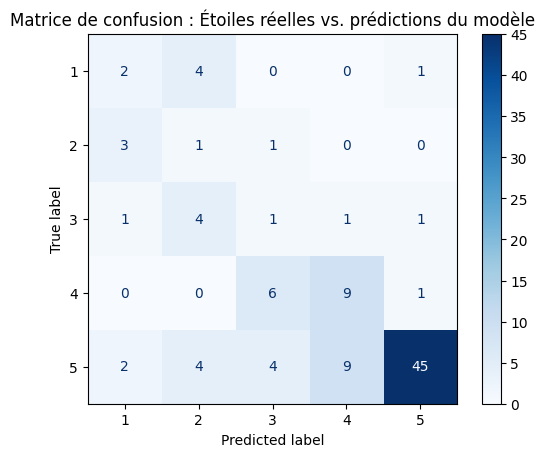

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Création de la matrice de confusion
cm = confusion_matrix(sample_df['stars'], sample_df['model_stars'], labels=[1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])

# Affichage
plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de confusion : Étoiles réelles vs. prédictions du modèle")
plt.show()

In [12]:
from sklearn.metrics import classification_report

# Génération du rapport complet : précision, rappel, F1-score, accuracy
rapport = classification_report(
    sample_df['stars'],
    sample_df['model_stars'],
    labels=[1, 2, 3, 4, 5],
    digits=2
)

print("Rapport d’évaluation du modèle :")
print(rapport)

Rapport d’évaluation du modèle :
              precision    recall  f1-score   support

           1       0.25      0.29      0.27         7
           2       0.08      0.20      0.11         5
           3       0.08      0.12      0.10         8
           4       0.47      0.56      0.51        16
           5       0.94      0.70      0.80        64

    accuracy                           0.58       100
   macro avg       0.36      0.38      0.36       100
weighted avg       0.70      0.58      0.63       100



In [13]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

# Téléchargement des stopwords français
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_fr = stopwords.words('french')

# Sélection d’un échantillon de 500 avis pour commencer
lda_df = df_clean.sample(500, random_state=1).copy()
corpus = lda_df['review_format'].astype(str).tolist()

# Vectorisation TF-IDF (avec suppression des stopwords)
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=stop_words_fr)
X = vectorizer.fit_transform(corpus)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
from sklearn.decomposition import LatentDirichletAllocation

# Application de LDA avec 5 topics (modifiable selon besoin)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [15]:
# Fonction pour afficher les mots principaux par thème
def afficher_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\n🟦 Thème {idx + 1}")
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print("Mots-clés :", ", ".join(top_features))

# Afficher les mots-clés des 5 thèmes extraits
afficher_topics(lda_model, vectorizer.get_feature_names_out())


🟦 Thème 1
Mots-clés : attractions, plus, parc, journée, magique, disney, attente, dommage, magie, attraction

🟦 Thème 2
Mots-clés : féerique, merveilleux, pleins, yeux, ans, aussi, toujours, come, magique, étoiles

🟦 Thème 3
Mots-clés : lt, inoubliable, journée, monde, magique, petits, grands, comme, disneyland, toujours

🟦 Thème 4
Mots-clés : retourner, rêve, adore, magique, endroit, enfants, manifique, juste, bien, tres

🟦 Thème 5
Mots-clés : trop, très, parc, attractions, tout, magnifique, bien, plus, journée, disney


In [16]:
# Transformation du corpus vectorisé en distribution de topics par document
topic_distribution = lda_model.transform(X)

# Pour chaque avis, on prend le numéro du topic dominant (celui avec la plus forte probabilité)
lda_df['topic_dominant'] = topic_distribution.argmax(axis=1)

# Affichage : un extrait avec texte + thème dominant
lda_df[['review_format', 'topic_dominant']].head(10)

,review_format,topic_dominant
20804,trop bien super week end avec le soleil en pl...,0
28038,un parc digne d un compte de fée,1
12143,à part le prix qui est abusé et les restaurant...,0
19233,c était la première fois que je retournai à di...,4
7907,encore une merveilleuse journée pour les ans ...,4
10588,visite des deux parcs vendredi janvier petit...,4
47373,magique mais un peu onéreux dommage,0
236806,juste magique,3
9402,beaucoup d attraction fermé mais féerique quan...,0
2229,prix trop élevé et beaucoup d attractions en p...,4


<ipython-input-17-2d805648d532>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lda_df, x='topic_dominant', palette='viridis')


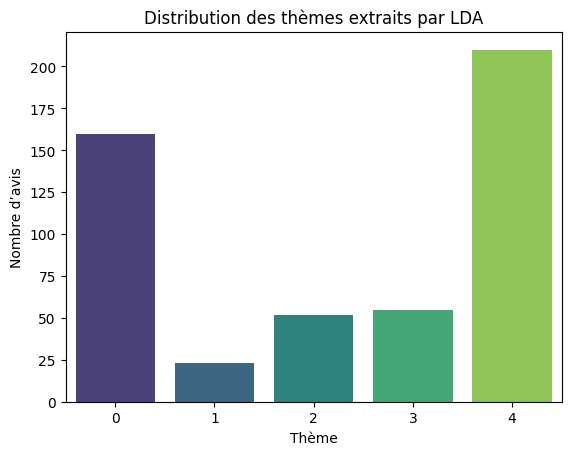

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Comptage des thèmes
sns.countplot(data=lda_df, x='topic_dominant', palette='viridis')
plt.title("Distribution des thèmes extraits par LDA")
plt.xlabel("Thème")
plt.ylabel("Nombre d’avis")
plt.show()

In [21]:
# Fonction simple pour afficher les top mots de chaque thème
def afficher_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\n🟩 Thème {idx + 1}")
        print("Mots-clés :", ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

afficher_topics(lda_model, vectorizer.get_feature_names_out())


🟩 Thème 1
Mots-clés : attractions, plus, parc, journée, magique, disney, attente, dommage, magie, attraction

🟩 Thème 2
Mots-clés : féerique, merveilleux, pleins, yeux, ans, aussi, toujours, come, magique, étoiles

🟩 Thème 3
Mots-clés : lt, inoubliable, journée, monde, magique, petits, grands, comme, disneyland, toujours

🟩 Thème 4
Mots-clés : retourner, rêve, adore, magique, endroit, enfants, manifique, juste, bien, tres

🟩 Thème 5
Mots-clés : trop, très, parc, attractions, tout, magnifique, bien, plus, journée, disney


In [22]:
# Filtrer tous les avis dont le thème dominant est par exemple 0 (le 1er thème)
theme_cible = 0  # Change ce nombre entre 0 et 4 si tu veux un autre thème

# Avis liés à ce thème
avis_theme = lda_df[lda_df['topic_dominant'] == theme_cible]['review_format']

# Affichage des 5 premiers avis
avis_theme.head(5).tolist()

['trop bien  super week end avec le soleil en plus  hôtel et resto au top  ',
 'à part le prix qui est abusé et les restaurants sont pas de tout donné et plein d attraction qui sont on arrêt pour un billet d entre de   par personne je trouve que mal honnête',
 'magique  mais un peu onéreux    dommage ',
 'beaucoup d attraction fermé mais féerique quand même',
 'on retrouve bien la magie de noël  mais tout est en anglais  quel dommage pour un établissement qui se situe sur la capitale française  je comprends qu on puisse faire des traductions mais qu il y ait plus d anglais que de français c est pas possible    dommage également pour les queues interminables dans les attractions  pour les problèmes techniques  et pour les prix exorbitants ']